<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/2_diagnostico/diagnos_prueba_inicial_pivu/49_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Button to open this notebook in Google Colab, featuring the Colab logo and the text Open In Colab."></a>
  </td>
</table>

In [ ]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


In [ ]:

# Ejemplo de uso:
generar_qr("https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/2_diagnostico/diagnos_prueba_inicial_pivu/49_.ipynb")



In [1]:
import pandas as pd
from random import choice

def estudiante_que_va_a_participar(ruta_archivo):
    try:
        # skiprows=2 hace que la lectura comience en la fila 3 del Excel
        # La fila 3 pasará a ser el encabezado (donde debe estar 'NOMBRES Y APELLIDOS')
        df = pd.read_excel(ruta_archivo, sheet_name=0, skiprows=2)
    except Exception as e:
        return f"Error al abrir el archivo: {e}"

    # Verificamos que la columna exista después del salto de filas
    if 'NOMBRES Y APELLIDOS' not in df.columns:
        return "Error: No se encontró la columna 'NOMBRES Y APELLIDOS' a partir de la fila 3."

    lista_estudiantes = df['NOMBRES Y APELLIDOS'].dropna().tolist()

    if lista_estudiantes:
        estudiante = choice(lista_estudiantes)
        print(f"El estudiante seleccionado es: {estudiante}")
        return estudiante
    else:
        print('Todos los estudiantes han participado o la lista está vacía.')
        return None
    
# Ruta del archivo
ruta = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_caucasia_notas_quices.xlsx"
estudiante_que_va_a_participar(ruta)

El estudiante seleccionado es: Andrés De Jesús  Baldovino Mangones


'Andrés De Jesús  Baldovino Mangones'

# Ejercicio 53 de la Prueba diagnóstica PIVU Caucasia  

¡Excelente! Este es un problema clásico de **Estrella Mágica** o **Distribución Numérica**, muy común en exámenes de razonamiento lógico. La clave aquí es la eficiencia: encontrar el número central sin tener que probar todas las combinaciones.

---



### 1. Transcripción y Edición del Problema

**Enunciado:**
53. En los círculos de la figura, se deben colocar los números del $1$ al $7$ (sin repetir) de modo que la suma de los $3$ números ubicados en los círculos unidos por cada una de las líneas (diámetros) sea siempre $12$.

**Pregunta:**
La cifra que debe ocupar el círculo central es:
(A) $3$
(B) $4$
(C) $5$
(D) $6$

---



### 2. Resolución Didáctica (Estrategia de < 2 minutos)

Para resolver esto rápidamente, utilizamos la **Propiedad de las Sumas Totales**.

**Paso 1: Identificar las líneas.**
Hay $3$ líneas que pasan por el centro. Cada línea suma $12$. Si sumamos las $3$ líneas, tenemos:
$$3 \times 12 = 36$$

**Paso 2: Analizar qué números estamos sumando.**
Al sumar las $3$ líneas, estamos usando los $6$ números de los extremos una vez, pero el **número central ($x$) lo estamos contando 3 veces**.
La suma de todos los números del $1$ al $7$ es:
$$S_{total} = 1 + 2 + 3 + 4 + 5 + 6 + 7 = 28$$

**Paso 3: Establecer la ecuación.**
La suma de las líneas ($36$) es igual a la suma de todos los números ($28$) más las veces extra que contamos el centro ($2x$ adicionales, ya que una vez ya está incluida en el 28):
$$28 + 2x = 36$$
$$2x = 36 - 28$$
$$2x = 8 \implies x = 4$$

**Respuesta Correcta:** El círculo central debe ser ocupado por el **4**. La opción correcta es la **(B)**.

---



### 3. Representación Gráfica (Grafo con Graphviz)

A continuación, genero el diagrama solicitado. He colocado el número $4$ en el centro y distribuido los demás números de forma que se cumpla la regla ($12$ por línea: $1+4+7$, $2+4+6$, $3+4+5$).


In [10]:
import graphviz
import os

# 1. Definir la ruta de guardado
ruta_descargas = r'C:\Users\marco\Downloads\estrella_magica'

# 2. Crear el objeto del grafo (especificando el motor 'neato' para usar posiciones 'pos')
dot = graphviz.Graph('EstrellaMagica', engine='neato', format='png')

# Configuración de estilo
dot.attr('node', shape='circle', style='filled', fillcolor='white', 
         fixedsize='true', width='0.6', fontname='Arial')

# Nodos y Posiciones (Centro = 4)
dot.node('C', '4', fillcolor='lightblue', pos='0,0!')
dot.node('N1', '1', pos='0,1.5!')
dot.node('S1', '7', pos='0,-1.5!')
dot.node('N2', '2', pos='1.3,0.75!')
dot.node('S2', '6', pos='-1.3,-0.75!')
dot.node('N3', '3', pos='1.3,-0.75!')
dot.node('S3', '5', pos='-1.3,0.75!')

# Conexiones por colores
dot.edge('N1', 'C', color='red', penwidth='2')
dot.edge('C', 'S1', color='red', penwidth='2')
dot.edge('N2', 'C', color='blue', penwidth='2')
dot.edge('C', 'S2', color='blue', penwidth='2')
dot.edge('N3', 'C', color='green', penwidth='2')
dot.edge('C', 'S3', color='green', penwidth='2')

# 3. LÍNEA PARA GUARDAR: 
# cleanup=True elimina el archivo fuente .gv y deja solo el .png
dot.render(ruta_descargas, view=True, cleanup=True)

print(f"El gráfico ha sido guardado en: {ruta_descargas}.png")

El gráfico ha sido guardado en: C:\Users\marco\Downloads\estrella_magica.png


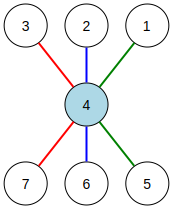

In [6]:
import graphviz

# Creamos el objeto del grafo
dot = graphviz.Graph('EstrellaMagica', comment='Problema 53', format='png')

# Configuración global de los nodos
dot.attr('node', shape='circle', style='filled', fillcolor='white', 
         fixedsize='true', width='0.6', fontname='Arial')

# Nodo central (La respuesta es 4)
dot.node('C', '4', fillcolor='lightblue', pos='0,0!')

# Nodos extremos (posiciones aproximadas para formar la estrella)
dot.node('N1', '3', pos='0,1.5!')
dot.node('S1', '7', pos='0,-1.5!')

dot.node('N2', '2', pos='1.3,0.75!')
dot.node('S2', '6', pos='-1.3,-0.75!')

dot.node('N3', '1', pos='1.3,-0.75!')
dot.node('S3', '5', pos='-1.3,0.75!')

# Definición de las líneas (las 3 líneas que deben sumar 12)
dot.edge('N1', 'C', color='red', penwidth='2')
dot.edge('C', 'S1', color='red', penwidth='2')

dot.edge('N2', 'C', color='blue', penwidth='2')
dot.edge('C', 'S2', color='blue', penwidth='2')

dot.edge('N3', 'C', color='green', penwidth='2')
dot.edge('C', 'S3', color='green', penwidth='2')

# Para visualizarlo en Jupyter/Colab:
dot



### 4. Representación de Datos con Pandas y Matplotlib

Presentamos una tabla con las combinaciones por línea para verificar la solución.



Verificación de Sumas:
     Línea  Extremo A  Centro  Extremo B  Suma Total
  Vertical          1       4          7          12
Diagonal 1          2       4          6          12
Diagonal 2          3       4          5          12


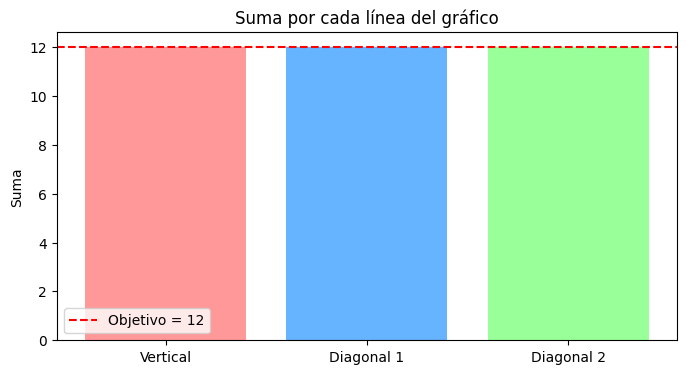

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos de las líneas
data = {
    'Línea': ['Vertical', 'Diagonal 1', 'Diagonal 2'],
    'Extremo A': [1, 2, 3],
    'Centro': [4, 4, 4],
    'Extremo B': [7, 6, 5],
    'Suma Total': [12, 12, 12]
}

df = pd.DataFrame(data)

# Mostrar tabla
print("Verificación de Sumas:")
print(df.to_string(index=False))

# Representación visual de las sumas
plt.figure(figsize=(8, 4))
plt.bar(df['Línea'], df['Suma Total'], color=['#ff9999','#66b3ff','#99ff99'])
plt.axhline(y=12, color='r', linestyle='--', label='Objetivo = 12')
plt.title('Suma por cada línea del gráfico')
plt.ylabel('Suma')
plt.legend()
plt.savefig("C:\\Users\\marco\\Downloads\\suma_lineas_grafico.png", bbox_inches='tight')
plt.show()


### Visualización Interactiva (Plotly)



In [8]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Table(
    header=dict(values=['Posición', 'Valor'], fill_color='royalblue', font=dict(color='white')),
    cells=dict(values=[['Centro', 'Línea 1 Extremos', 'Línea 2 Extremos', 'Línea 3 Extremos'],
                       [4, '1 y 7', '2 y 6', '3 y 5']], fill_color='lavender')
)])

fig.update_layout(title="Distribución Final de los Números")
fig.show()
fig.write_image("C:\\Users\\marco\\Downloads\\distribucion_final_numeros.png")



¿Deseas que analicemos algún otro problema de lógica de los archivos que subiste?